# Aerial Scene Classification via Transfer Learning
### A Computer Vision Study Using EuroSAT satellite imagery
**Author:** Jory Pitts

**Date:** June 16, 2026

**Repository:** https://github.com/jpitts-dev/aerial-scene-classifier

---
---
## Abstract

This project applies transfer learning to the problem of aerial scene classification using the EuroSAT RGB dataset, a collection of 27,000 satellite images across 10 land use categories captured by the Sentinel-2 satellite. A pretrained ResNet18 convolutional neural network is fine-tuned to classify terrain types including forest, highway, residential, and agricultural land. The goal is to explore whether a model trained on general images can be adapted to understand satellite imagery with limited computational resources. This work covers core computer vision concepts including image data pipelines, pretrained model adaptation, and classification performance analysis, with applications in autonomous drone navigation, aerial reconnaissance, and intelligent image understanding systems.

---
## Introduction

Satellite and aerial imagery captures detailed information about the physical world, but making sense of that imagery at scale requires a model that can recognize meaningful visual patterns across thousands of images. This project explores that challenge through the task of land use classification, identifying what type of terrain appears in a given satellite image.

The EuroSAT dataset provides a strong foundation for this task. It contains 27,000 labeled RGB images across 10 terrain categories, collected from the Sentinel-2 satellite over European landscapes. Each image is 64x64 pixels, with each pixel representing a 10x10 meter area on the ground.

Rather than attempting to build a neural network from scratch, this project uses transfer learning, a technique where a model already trained on a large image dataset is adapted to a new, more specific task. The pretrained model used here is ResNet18, trained on ImageNet. The idea is that a model which already understands general visual features like edges, textures, and shapes can be retrained to recognize terrain types with far less data and compute than starting from zero.

The central question driving this project is whether a fine-tuned ResNet18 can reliably classify terrain from satellite imagery, and where it succeeds or struggles across the ten categories.

---
## Methods

Before writing any modeling code, the dataset is explored to understand what we are actually working with. This includes verifying the folder structure loaded correctly, checking how many images exist per terrain category, and visualizing sample images from each class. Looking at the data first helps catch any obvious problems early and builds intuition for what the model will be learning from.

---
## Data Analysis

In [18]:
import os
import torch
import torchvision
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from PIL import Image
from collections import Counter

# Path to EuroSAT RGB dataset
DATA_DIR = Path("data/EuroSAT")

# Read class names from folder
class_names = []
for item in DATA_DIR.iterdir():
    if item.is_dir():
        class_names.append(item.name)
    class_names = sorted(class_names)

print(f"Number of classes: {len(class_names)}")
print(f"Classes: {class_names}")

Number of classes: 10
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [19]:
# Count the number of images in each class
class_counts = {}
for class_name in class_names:
    class_folder = DATA_DIR / class_name
    count = 0
    for image in class_folder.iterdir():
        if image.suffix == ".jpg":
            count += 1
        class_counts[class_name] = count

# Display counts
for class_name, count in class_counts.items():
    print(f"Class {class_name}: {count} images")

Class AnnualCrop: 3000 images
Class Forest: 3000 images
Class HerbaceousVegetation: 3000 images
Class Highway: 2500 images
Class Industrial: 2500 images
Class Pasture: 2000 images
Class PermanentCrop: 2500 images
Class Residential: 3000 images
Class River: 2500 images
Class SeaLake: 3000 images


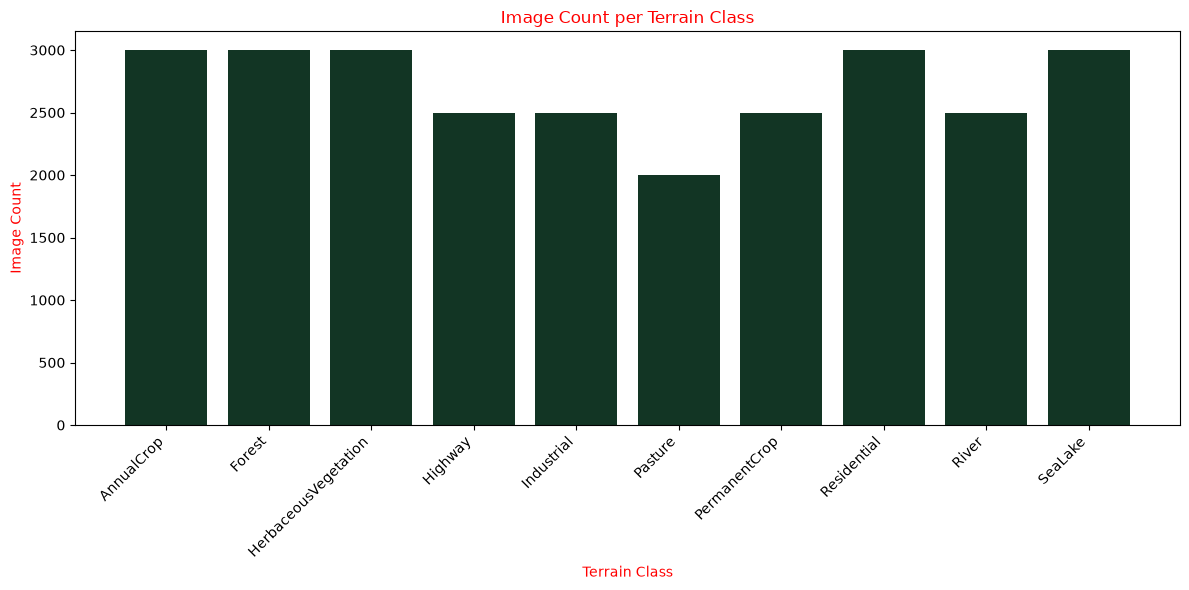

In [20]:
# Visualize class distribution with a bar chart
plt.figure(figsize=(12, 6))
plt.bar(class_counts.keys(), class_counts.values(), color="#123524")
plt.title("Image Count per Terrain Class", color="red")
plt.xlabel("Terrain Class", color="red")
plt.ylabel("Image Count", color="red")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

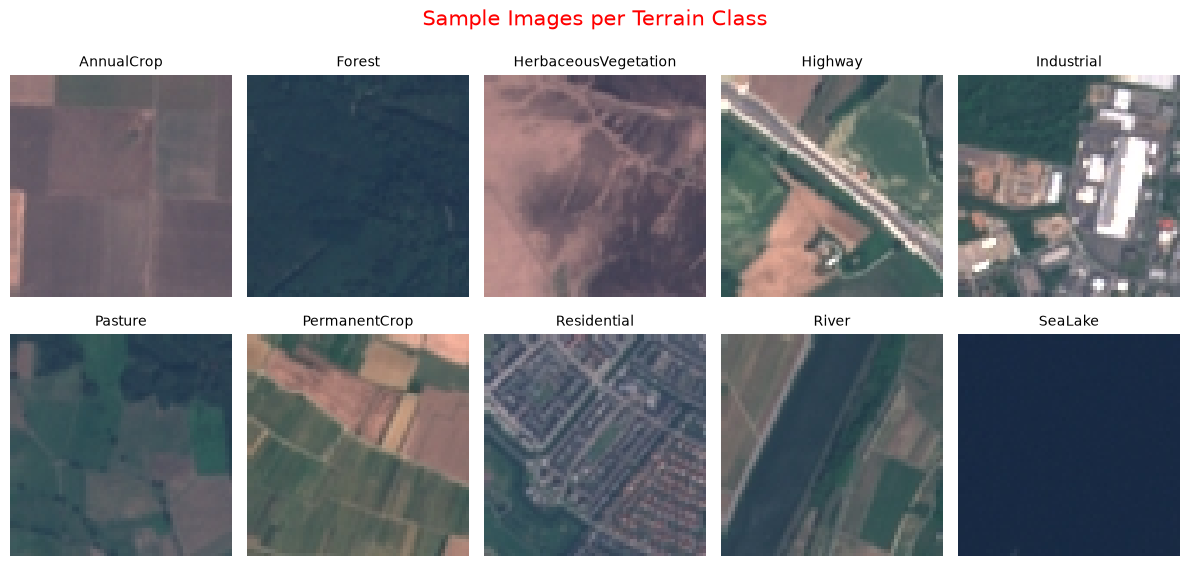

In [21]:
# Display a sample image from each class
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for i, class_name in enumerate(class_names):
    class_folder = DATA_DIR / class_name

    # Get first image in the folder
    images = []
    for image in class_folder.iterdir():
        if image.suffix == ".jpg":
            images.append(image)

    sample_image = Image.open(images[0])

    axes[i].imshow(sample_image)
    axes[i].set_title(class_name, fontsize=10)
    axes[i].axis("off")

plt.suptitle("Sample Images per Terrain Class", color="red", fontsize=15)
plt.tight_layout()
plt.show()

Visual inspection of sample images show that several terrain classes share similar characteristics. AnnualCrop, PermanentCrop, and Pasture all display green vegetation with open land patterns, suggesting these categories may be the most difficult for the model to distinguish.

---
## Data Preprocessing
Before images can be given to the model, they must be transformed in a way ResNet18 expects. This involves resizing each image from 64x64 to 224x224, converting it to a PyTorch tensor, and normalizing the pixel values using the mean and standard deviation values from the ImageNet dataset ResNet18 was originally trained on. Matching these expectations allows the pretrained weights to work effectively on our new data.

In [22]:
from torchvision import transforms
# Define the image transformation pipeline
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transformation pipeline defined successfully.")

Transformation pipeline defined successfully.


In [23]:
from torchvision import datasets
from torch.utils.data import DataLoader, random_split

# Load the full dataset from the folder
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=transform)

# Calculate split sizes
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

# Split dataset
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size],
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Total Images: {total_size}")
print(f"Training Images: {train_size}")
print(f"Validation Images: {val_size}")
print(f"Test Images: {test_size}")

Total Images: 27000
Training Images: 21600
Validation Images: 2700
Test Images: 2700


---
## Model
This project uses ResNet18, a convolutional neural network pretrained on the ImageNet dataset. Rather than training a network from scratch, only the final classification layer is replaced and retrained to output predictions across the 10 EuroSAT terrain categories. This approach is called transfer learning.

In [24]:
import torchvision.models as models
import torch.nn as nn

# Load th pretrained ResNet18 model
model = models.resnet18(weights="IMAGENET1K_V1")

# Freeze all layers so only the final layer will be trained
for param in model.parameters():
    param.requires_grad = False

# Replace the final classification layer with one that outputs the 10 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)

print(model.fc)
print(f"Output classes: 10")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Jory_/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


Linear(in_features=512, out_features=10, bias=True)
Output classes: 10


In [25]:
import torch.optim as optim

# Move model to GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Define loss function
criterion = nn.CrossEntropyLoss()

# Define optimizer
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print(f"Training on: {device}")
print("Loss function and optimizer defined successfully.")

Training on: cpu
Loss function and optimizer defined successfully.
